# PCA Implementation


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_regression

In [11]:
#load the data

data = pd.read_csv(r'audi.csv')
data.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,A1,2017,12500,Manual,15735,Petrol,150,55.4,1.4
1,A6,2016,16500,Automatic,36203,Diesel,20,64.2,2.0
2,A1,2016,11000,Manual,29946,Petrol,30,55.4,1.4
3,A4,2017,16800,Automatic,25952,Diesel,145,67.3,2.0
4,A3,2019,17300,Manual,1998,Petrol,145,49.6,1.0


In [13]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10668 entries, 0 to 10667
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         10668 non-null  str    
 1   year          10668 non-null  int64  
 2   price         10668 non-null  int64  
 3   transmission  10668 non-null  str    
 4   mileage       10668 non-null  int64  
 5   fuelType      10668 non-null  str    
 6   tax           10668 non-null  int64  
 7   mpg           10668 non-null  float64
 8   engineSize    10668 non-null  float64
dtypes: float64(2), int64(4), str(3)
memory usage: 925.1 KB


There is no any null value means the whole data is clean

In [15]:
data.shape

(10668, 9)

In [18]:
numeric_data = data[['year','price','mileage','tax','mpg','engineSize']]
numeric_data.head()

,year,price,mileage,tax,mpg,engineSize
0,2017,12500,15735,150,55.4,1.4
1,2016,16500,36203,20,64.2,2.0
2,2016,11000,29946,30,55.4,1.4
3,2017,16800,25952,145,67.3,2.0
4,2019,17300,1998,145,49.6,1.0


In [19]:
numeric_data.shape

(10668, 6)

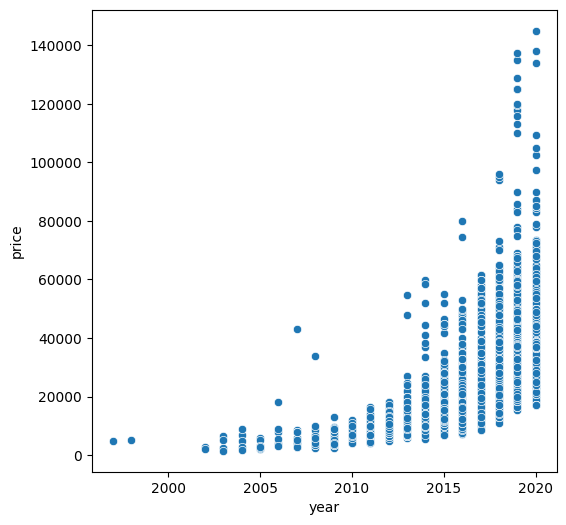

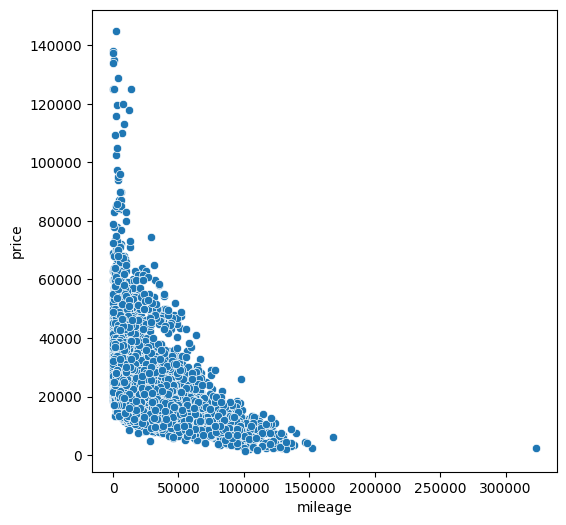

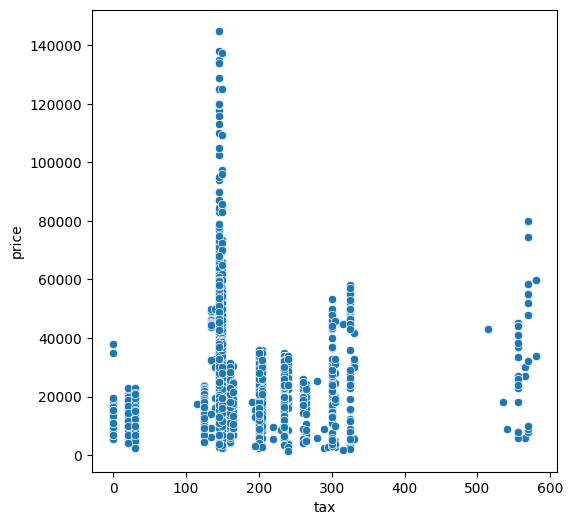

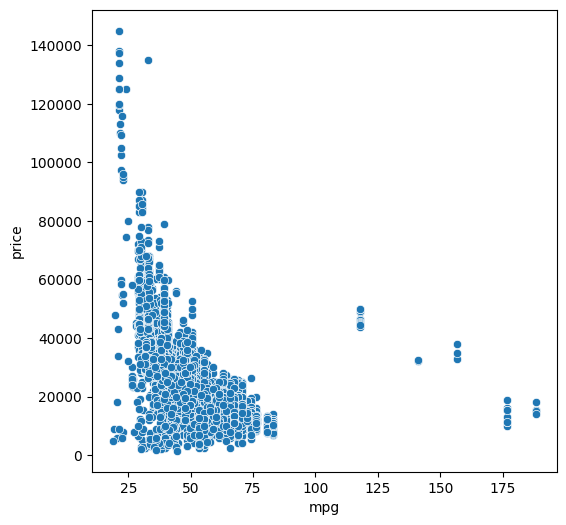

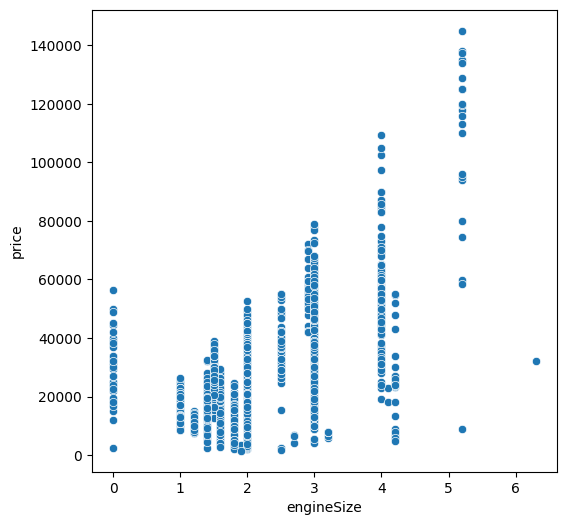

In [20]:
y = numeric_data['price']
bmw_ = numeric_data.drop('price', axis=1)

cols = [col for col in bmw_.columns if bmw_[col].dtype in ['int64','float64']]

for idx, col in enumerate(cols):
    plt.figure(idx, figsize=(6,6))
    sns.scatterplot(x=col, y=y, data=bmw_)
    plt.show

In [22]:
#### STANDARDIZATION #####

# Mean of the data 
numeric_data_mean = numeric_data.mean()

# Standard deviation of the data
numeric_data_std = numeric_data.std()

# Scaled the data
numeric_data_scaled = (numeric_data - numeric_data_mean)/numeric_data_std
numeric_data_scaled

,year,price,mileage,tax,mpg,engineSize
0,-0.046448,-0.887480,-0.386817,0.357131,0.357533,-0.880177
1,-0.507810,-0.546033,0.483966,-1.578249,1.037081,0.114919
2,-0.507810,-1.015522,0.217771,-1.429373,0.357533,-0.880177
3,-0.046448,-0.520424,0.047851,0.282693,1.276468,0.114919
4,0.876277,-0.477743,-0.971240,0.282693,-0.090351,-1.543575
...,...,...,...,...,...,...
10663,1.337639,-0.503437,-0.885302,0.282693,-0.090351,-1.543575
10664,1.337639,-0.503437,-0.972091,0.357131,-0.090351,-1.543575
10665,1.337639,-0.486365,-1.030333,0.357131,-0.090351,-1.543575
10666,-0.046448,-0.290033,-0.688410,0.357131,-0.221627,-0.880177


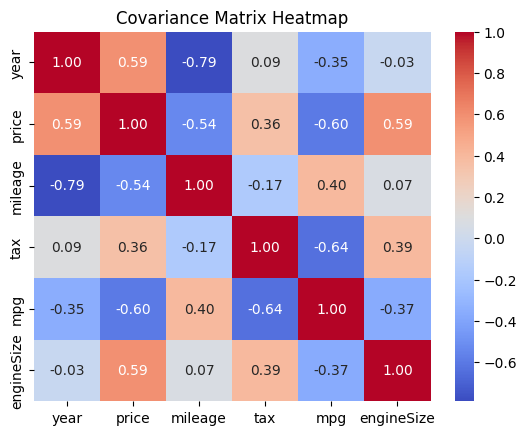

In [25]:
### COVRIANCE MATRIX ###

n = numeric_data.shape[0]
covriance_matrix = (1/(n-1))*numeric_data_scaled.T.dot(numeric_data_scaled)


# Plotting
sns.heatmap(covriance_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Covariance Matrix Heatmap')
plt.show()

In [28]:
### EIGENVALUES AND EIGENVECTORS ###

eigen_values , eigen_vectors = np.linalg.eig(covriance_matrix)

print("Eigen Values is :",eigen_values)
print("Eigen Vectors is :", eigen_vectors)

Eigen Values is : [3.00600026 1.55286623 0.78562111 0.13386766 0.20305466 0.31859008]
Eigen Vectors is : [[-0.40282543 -0.50443824 -0.10088103  0.37645692  0.63995831  0.1477508 ]
 [-0.51016611  0.03785255 -0.41901248 -0.73835396  0.0976721  -0.08955372]
 [ 0.4047773   0.49359229 -0.08336572 -0.08457989  0.72984732 -0.21387209]
 [-0.34511511  0.40349442  0.59569749 -0.1298729   0.13908837  0.57185643]
 [ 0.46372679 -0.19415189 -0.372847   -0.20625118  0.02788077  0.75161875]
 [-0.28190526  0.54769809 -0.55984939  0.49654138 -0.16767081  0.18016117]]


In [33]:
## Sorting of eigenvalues and eigenvectors

idx = np.argsort(eigen_values)[::-1]

eigen_values_sorted = eigen_values[idx]
eigen_vectors_sorted = eigen_vectors[:,idx]

print(eigen_values_sorted)
print(eigen_vectors_sorted)

[3.00600026 1.55286623 0.78562111 0.31859008 0.20305466 0.13386766]
[[-0.40282543 -0.50443824 -0.10088103  0.1477508   0.63995831  0.37645692]
 [-0.51016611  0.03785255 -0.41901248 -0.08955372  0.0976721  -0.73835396]
 [ 0.4047773   0.49359229 -0.08336572 -0.21387209  0.72984732 -0.08457989]
 [-0.34511511  0.40349442  0.59569749  0.57185643  0.13908837 -0.1298729 ]
 [ 0.46372679 -0.19415189 -0.372847    0.75161875  0.02788077 -0.20625118]
 [-0.28190526  0.54769809 -0.55984939  0.18016117 -0.16767081  0.49654138]]


In [36]:
total = sum(eigen_values_sorted)
var_explained = [(i/total)*100 for i in sorted(eigen_values_sorted, reverse=True)]

#calculate cumulative variance
cum_var_explained = np.cumsum(var_explained)
print(var_explained)

[np.float64(50.100004287997294), np.float64(25.881103904615347), np.float64(13.093685165273358), np.float64(5.309834685553131), np.float64(3.384244313541008), np.float64(2.231127643019855)]


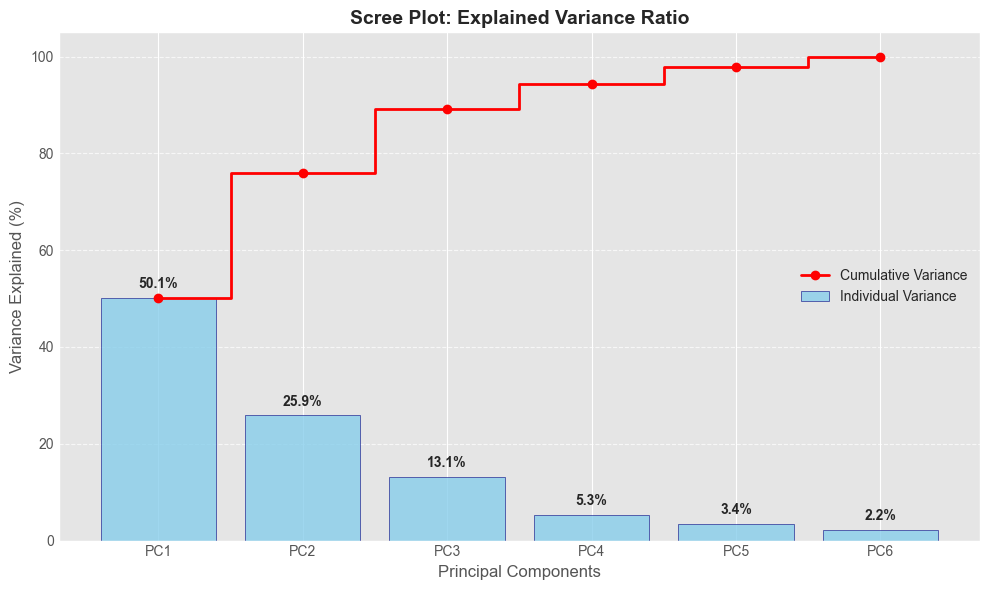

In [37]:
# 1. Setup the figure
plt.figure(figsize=(10, 6))
plt.style.use('ggplot')

# 2. Create x-axis labels
x_labels = [f'PC{i+1}' for i in range(len(var_explained))]
x_pos = range(len(var_explained))

# 3. Plot Individual Variance (Bars)
plt.bar(x_pos, var_explained, alpha=0.8, color='skyblue', 
        edgecolor='navy', label='Individual Variance')

# 4. Plot Cumulative Variance (Step/Line)
plt.step(x_pos, cum_var_explained, where='mid', color='red', 
         marker='o', lw=2, label='Cumulative Variance')

# 5. Add Labels and Styling
plt.ylabel('Variance Explained (%)', fontsize=12)
plt.xlabel('Principal Components', fontsize=12)
plt.title('Scree Plot: Explained Variance Ratio', fontsize=14, fontweight='bold')
plt.xticks(x_pos, x_labels)
plt.ylim(0, 105) # Extra room for labels
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 6. Add value annotations on top of bars
for i, v in enumerate(var_explained):
    plt.text(i, v + 2, f"{v:.1f}%", ha='center', fontweight='bold')

plt.legend(loc='center right')
plt.tight_layout()
plt.show()


In [42]:
# transforming original dataframe into PCA

vect = np.array(eigen_vectors_sorted)

# dot product to create principal components analysis

X_vect_pca = np.dot(numeric_data_scaled, vect.T)

pd.DataFrame(X_vect_pca)

,0,1,2,3,4,5
0,0.455635,0.805005,-0.165597,-0.204222,0.754922,-0.689069
1,0.904939,0.193392,0.569321,-0.529981,-1.490946,-0.828020
2,0.381125,0.942188,-0.083866,-0.758136,-1.002353,-1.289474
3,1.178321,-0.001546,0.581779,0.158823,0.286025,-0.404765
4,-0.611157,1.047395,0.204008,-0.724187,1.389554,-0.665307
...,...,...,...,...,...,...
10663,-0.792714,0.775041,0.370910,-0.842584,1.576447,-0.857553
10664,-0.772961,0.804741,0.362225,-0.851716,1.664755,-0.795553
10665,-0.775697,0.829791,0.375508,-0.879523,1.683156,-0.753596
10666,-0.185953,0.897423,-0.268258,-0.223368,0.735227,-0.095894
